# 🎓 Predicting Student GPA from Behavioral & Demographic Factors

**Mission:** To leverage machine learning to understand and predict academic performance based on student study habits, attendance, parental background, and engagement — enabling early intervention strategies for at-risk students.

**Dataset:** [Students Performance Dataset – Kaggle (Rabie El Kharoua)](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset)  
**Target Variable:** `GPA` (continuous — regression task)  
**Features include:** Study hours/week, absences, parental education, tutoring, extracurriculars, sports, music, volunteering, etc.

## 1. Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load Dataset

> **Download:** Go to https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset  
> Download `Student_performance_data _.csv` and place it in the same folder as this notebook.

In [2]:
# Load the dataset
df = pd.read_csv('Student_performance_data _.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2392, 15)
Columns: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Descriptive Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB

==

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


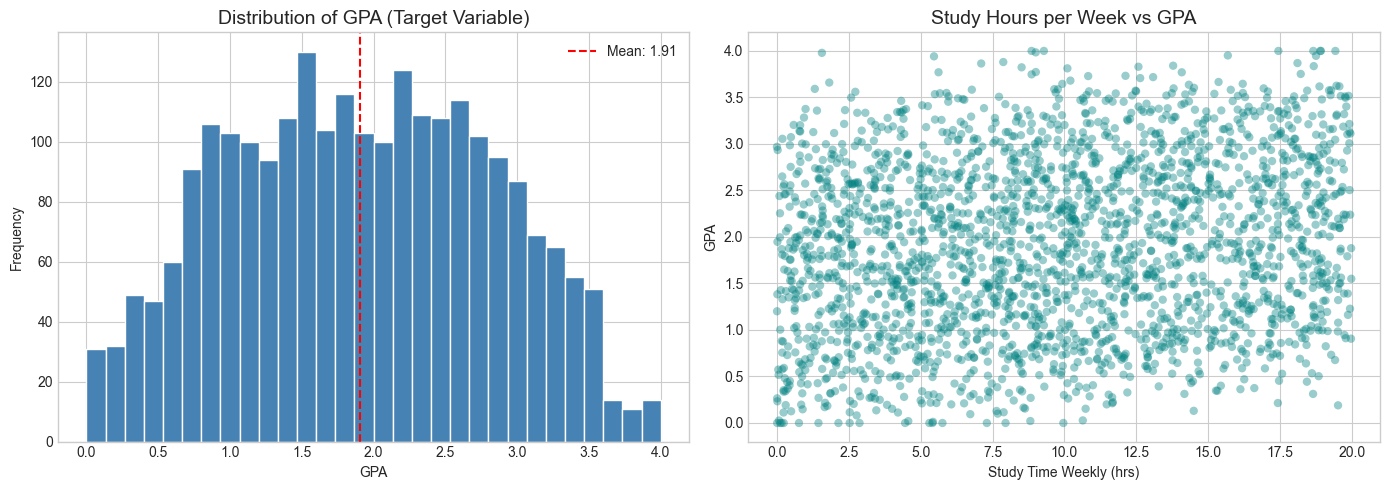

Interpretation: GPA is roughly normally distributed. A positive trend between study time and GPA is visible — students who study more tend to score higher.


In [4]:
# --- Visualization 1: GPA Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['GPA'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of GPA (Target Variable)', fontsize=14)
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['GPA'].mean(), color='red', linestyle='--', label=f'Mean: {df["GPA"].mean():.2f}')
axes[0].legend()

axes[1].scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.4, color='teal', edgecolors='none')
axes[1].set_title('Study Hours per Week vs GPA', fontsize=14)
axes[1].set_xlabel('Study Time Weekly (hrs)')
axes[1].set_ylabel('GPA')

plt.tight_layout()
plt.savefig('viz1_gpa_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: GPA is roughly normally distributed. A positive trend between study time and GPA is visible — students who study more tend to score higher.')

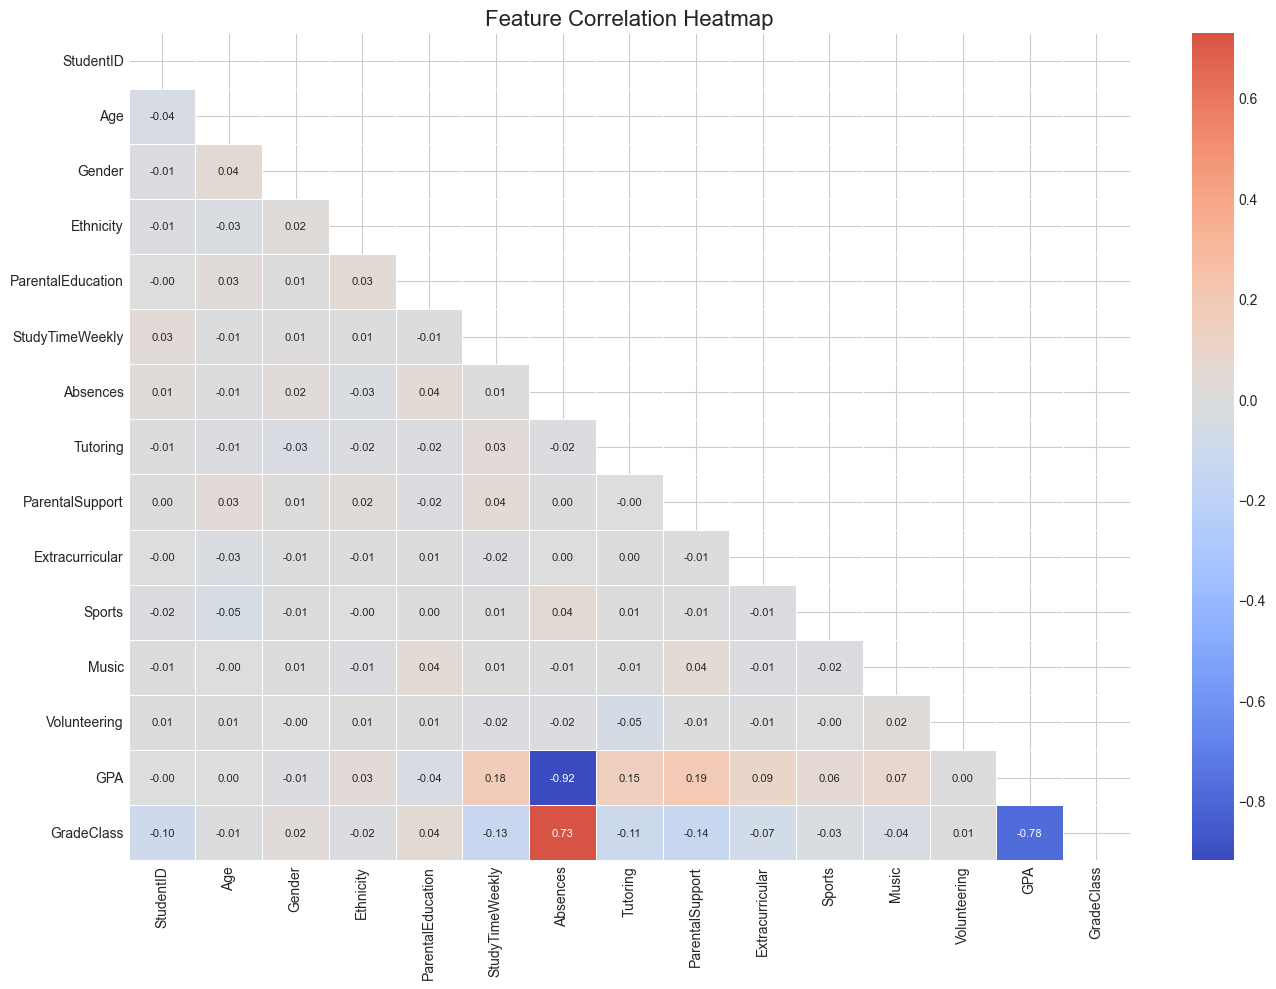


📊 Top Features Correlated with GPA:
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
StudentID           -0.002697
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314


In [5]:
# --- Visualization 2: Correlation Heatmap ---

# Encode categorical columns temporarily for correlation
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(14, 10))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('viz2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with GPA
gpa_corr = corr_matrix['GPA'].drop('GPA').sort_values(ascending=False)
print('\n📊 Top Features Correlated with GPA:')
print(gpa_corr.to_string())

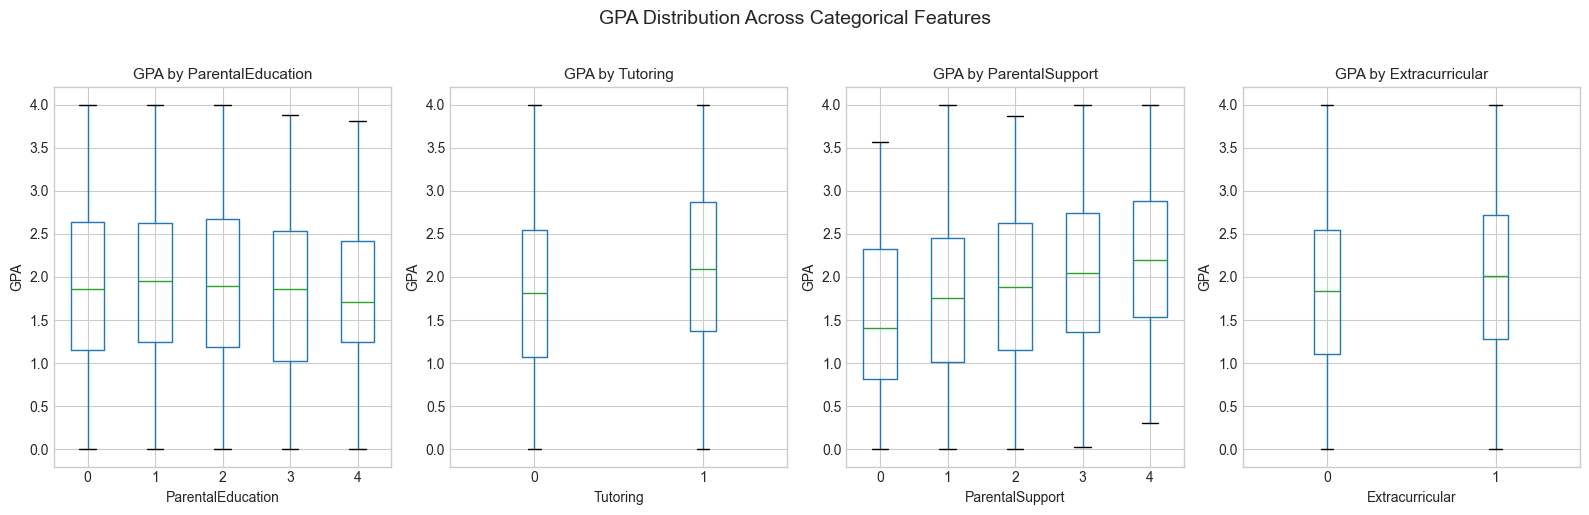

Interpretation: Students with higher parental education and support tend to have higher GPA. Tutoring also shows a noticeable positive impact on academic performance.


In [6]:
# --- Visualization 3: Feature Distributions vs GPA (Box plots) ---
categorical_cols = ['ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular']
existing_cats = [c for c in categorical_cols if c in df.columns]

fig, axes = plt.subplots(1, len(existing_cats), figsize=(16, 5))
if len(existing_cats) == 1:
    axes = [axes]

for ax, col in zip(axes, existing_cats):
    df.boxplot(column='GPA', by=col, ax=ax)
    ax.set_title(f'GPA by {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('GPA')

plt.suptitle('GPA Distribution Across Categorical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('viz3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Students with higher parental education and support tend to have higher GPA. Tutoring also shows a noticeable positive impact on academic performance.')

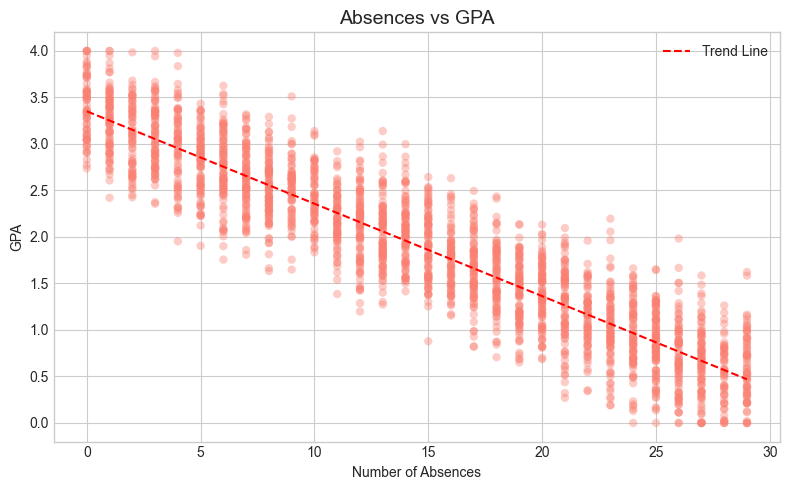

Interpretation: A clear negative correlation — higher absences strongly predict lower GPA. This is one of the most impactful predictors.


In [7]:
# --- Visualization 4: Absences vs GPA ---
plt.figure(figsize=(8, 5))
plt.scatter(df['Absences'], df['GPA'], alpha=0.4, color='salmon', edgecolors='none')
z = np.polyfit(df['Absences'], df['GPA'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Absences'].min(), df['Absences'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', label='Trend Line')
plt.title('Absences vs GPA', fontsize=14)
plt.xlabel('Number of Absences')
plt.ylabel('GPA')
plt.legend()
plt.tight_layout()
plt.savefig('viz4_absences_gpa.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: A clear negative correlation — higher absences strongly predict lower GPA. This is one of the most impactful predictors.')

## 4. Feature Engineering & Preprocessing

In [8]:
print('=== Column Types ===')
print(df.dtypes)
print('\n=== Unique values for object columns ===')
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].unique()[:10]}')

=== Column Types ===
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

=== Unique values for object columns ===


In [9]:
df_model = df.copy()

# ── Drop ID column if present ──────────────────────────────────────────────
id_cols = [c for c in df_model.columns if c.lower() in ['studentid', 'id', 'student_id']]
if id_cols:
    df_model.drop(columns=id_cols, inplace=True)
    print(f'Dropped ID columns: {id_cols}')

# ── Drop GradeClass if it exists (it's derived from GPA — data leakage) ───
if 'GradeClass' in df_model.columns:
    df_model.drop(columns=['GradeClass'], inplace=True)
    print('Dropped GradeClass (derived from GPA — would cause data leakage)')

# ── Encode categorical features ───────────────────────────────────────────
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'GPA']
print(f'\nCategorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f'  Encoded: {col}')

# ── Verify no missing values ──────────────────────────────────────────────
print(f'\nMissing values after preprocessing: {df_model.isnull().sum().sum()}')
print(f'Final shape: {df_model.shape}')
df_model.head()

Dropped ID columns: ['StudentID']
Dropped GradeClass (derived from GPA — would cause data leakage)

Categorical columns to encode: []

Missing values after preprocessing: 0
Final shape: (2392, 13)


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


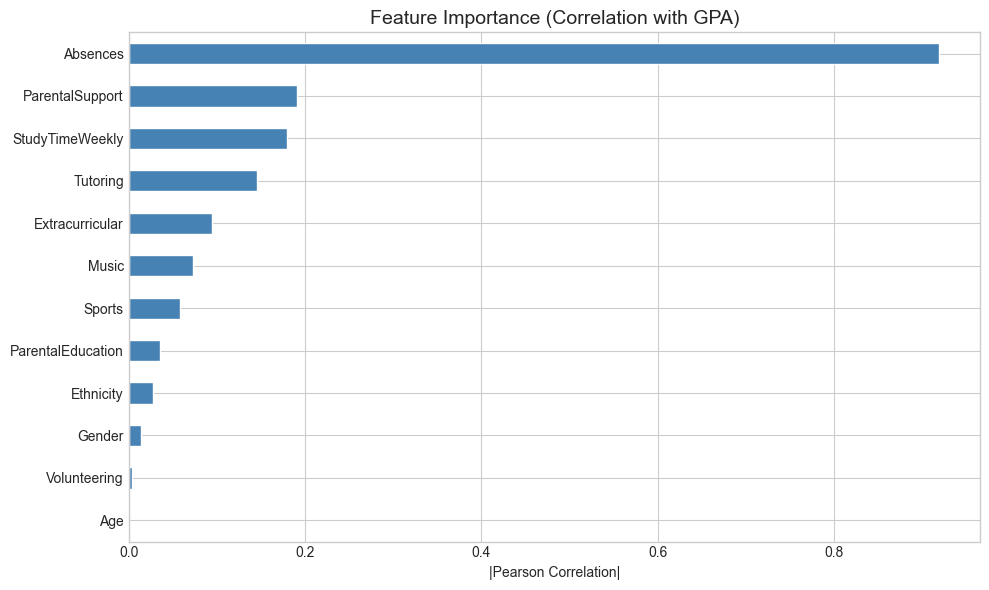

Top 5 predictors of GPA:
Absences           0.919314
ParentalSupport    0.190774
StudyTimeWeekly    0.179275
Tutoring           0.145119
Extracurricular    0.094078
Name: GPA, dtype: float64


In [10]:
# ── Feature Importance Preview via Correlation ────────────────────────────
feature_importance = df_model.corr()['GPA'].drop('GPA').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance (Correlation with GPA)', fontsize=14)
plt.xlabel('|Pearson Correlation|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('viz5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 predictors of GPA:')
print(feature_importance.head())

## 5. Train / Test Split & Standardization

In [11]:
X = df_model.drop(columns=['GPA'])
y = df_model['GPA']

print(f'Features: {list(X.columns)}')
print(f'Target: GPA')
print(f'X shape: {X.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'\nTrain size: {X_train.shape[0]} rows')
print(f'Test  size: {X_test.shape[0]} rows')

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Data standardized (mean=0, std=1)')

Features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Target: GPA
X shape: (2392, 12)

Train size: 1913 rows
Test  size: 479 rows

✅ Data standardized (mean=0, std=1)


## 6. Model 1: Linear Regression (with Gradient Descent via SGDRegressor)

In [12]:
# ── 6a. Scikit-learn LinearRegression (closed-form) ───────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse  = mean_squared_error(y_test,  y_pred_lr_test)
lr_r2        = r2_score(y_test, y_pred_lr_test)
lr_mae       = mean_absolute_error(y_test, y_pred_lr_test)

print('📈 Linear Regression (Closed-Form)')
print(f'  Train MSE : {lr_train_mse:.4f}')
print(f'  Test  MSE : {lr_test_mse:.4f}')
print(f'  Test  R²  : {lr_r2:.4f}')
print(f'  Test  MAE : {lr_mae:.4f}')

📈 Linear Regression (Closed-Form)
  Train MSE : 0.0385
  Test  MSE : 0.0387
  Test  R²  : 0.9532
  Test  MAE : 0.1553


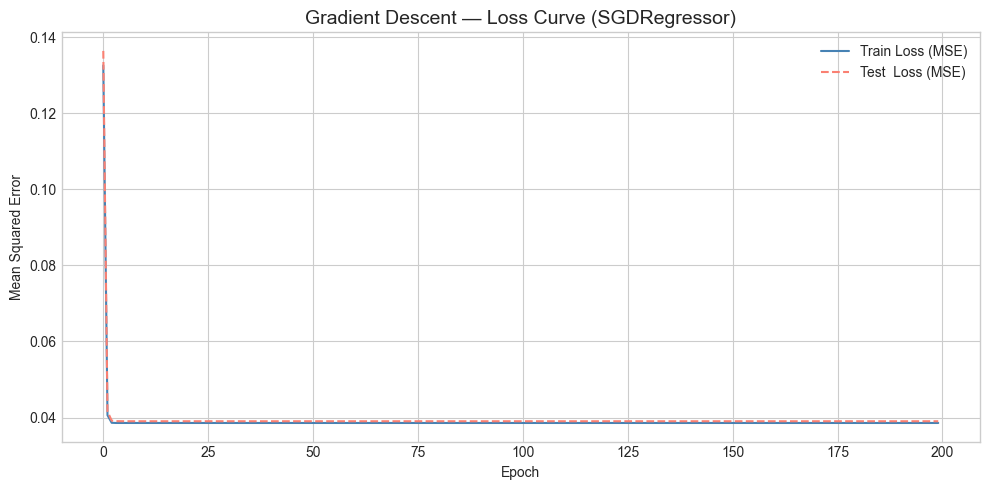


SGD Final Test MSE : 0.0390
SGD Final Test R²  : 0.9528
Interpretation: Loss decreases and converges — gradient descent is working correctly. Train and test loss tracks closely, indicating no significant overfitting.


In [13]:
# ── 6b. Gradient Descent via SGDRegressor (loss curve) ───────────────────
n_epochs = 200
train_losses = []
test_losses  = []

sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                   learning_rate='constant', eta0=0.001, penalty=None)

for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  sgd.predict(X_test_scaled)))

# Plot Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss (MSE)', color='steelblue')
plt.plot(test_losses,  label='Test  Loss (MSE)', color='salmon', linestyle='--')
plt.title('Gradient Descent — Loss Curve (SGDRegressor)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.savefig('viz6_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

sgd_r2  = r2_score(y_test, sgd.predict(X_test_scaled))
print(f'\nSGD Final Test MSE : {test_losses[-1]:.4f}')
print(f'SGD Final Test R²  : {sgd_r2:.4f}')
print('Interpretation: Loss decreases and converges — gradient descent is working correctly. Train and test loss tracks closely, indicating no significant overfitting.')

Using top feature for scatter plot: Absences


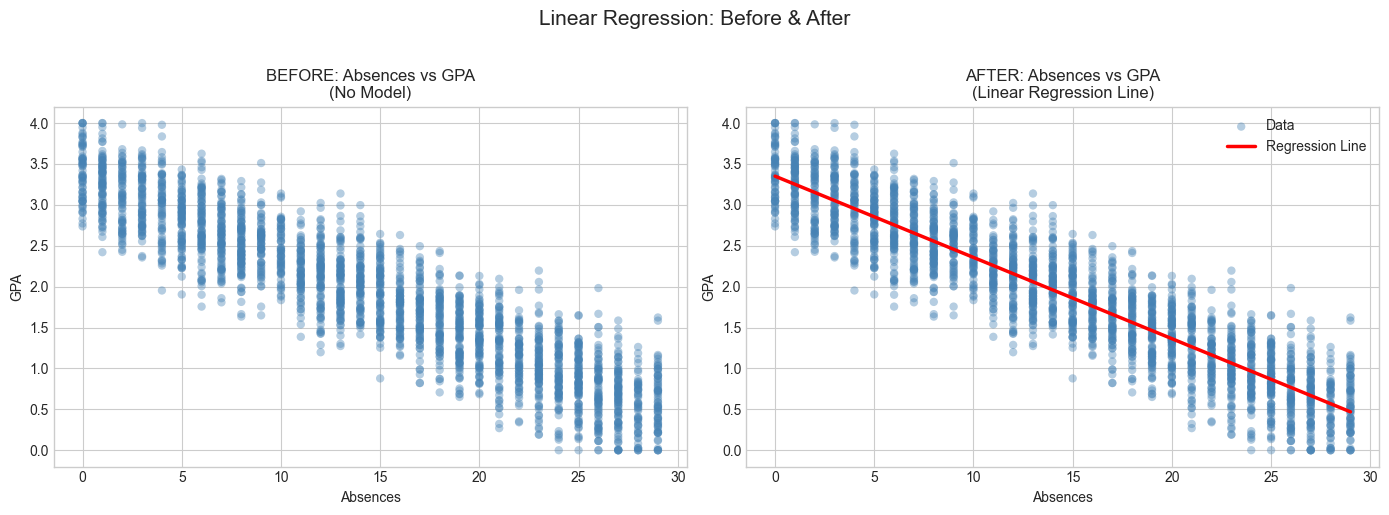

In [14]:
# ── 6c. Scatter plot: Before vs After (Raw data + Fitted Line) ─────────────
# Use the most correlated numeric feature for 2D visualization
top_feature = feature_importance.index[0]
print(f'Using top feature for scatter plot: {top_feature}')

X_vis = X[[top_feature]]
X_vis_scaled = StandardScaler().fit_transform(X_vis)

lr_vis = LinearRegression()
lr_vis.fit(X_vis_scaled, y)
y_vis_pred = lr_vis.predict(X_vis_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE — raw scatter
axes[0].scatter(X[top_feature], y, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].set_title(f'BEFORE: {top_feature} vs GPA\n(No Model)', fontsize=12)
axes[0].set_xlabel(top_feature)
axes[0].set_ylabel('GPA')

# AFTER — scatter + regression line
sorted_idx = X[top_feature].argsort()
axes[1].scatter(X[top_feature], y, alpha=0.4, color='steelblue', edgecolors='none', label='Data')
axes[1].plot(X[top_feature].values[sorted_idx],
             y_vis_pred[sorted_idx],
             color='red', linewidth=2.5, label='Regression Line')
axes[1].set_title(f'AFTER: {top_feature} vs GPA\n(Linear Regression Line)', fontsize=12)
axes[1].set_xlabel(top_feature)
axes[1].set_ylabel('GPA')
axes[1].legend()

plt.suptitle('Linear Regression: Before & After', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('viz7_before_after_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model 2: Decision Tree Regressor

In [15]:
dt = DecisionTreeRegressor(max_depth=6, min_samples_split=10, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt_train = dt.predict(X_train_scaled)
y_pred_dt_test  = dt.predict(X_test_scaled)

dt_train_mse = mean_squared_error(y_train, y_pred_dt_train)
dt_test_mse  = mean_squared_error(y_test,  y_pred_dt_test)
dt_r2        = r2_score(y_test, y_pred_dt_test)
dt_mae       = mean_absolute_error(y_test, y_pred_dt_test)

print('🌳 Decision Tree Regressor')
print(f'  Train MSE : {dt_train_mse:.4f}')
print(f'  Test  MSE : {dt_test_mse:.4f}')
print(f'  Test  R²  : {dt_r2:.4f}')
print(f'  Test  MAE : {dt_mae:.4f}')

🌳 Decision Tree Regressor
  Train MSE : 0.0689
  Test  MSE : 0.1016
  Test  R²  : 0.8772
  Test  MAE : 0.2504


## 8. Model 3: Random Forest Regressor

In [16]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                           min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test  = rf.predict(X_test_scaled)

rf_train_mse = mean_squared_error(y_train, y_pred_rf_train)
rf_test_mse  = mean_squared_error(y_test,  y_pred_rf_test)
rf_r2        = r2_score(y_test, y_pred_rf_test)
rf_mae       = mean_absolute_error(y_test, y_pred_rf_test)

print('🌲 Random Forest Regressor')
print(f'  Train MSE : {rf_train_mse:.4f}')
print(f'  Test  MSE : {rf_test_mse:.4f}')
print(f'  Test  R²  : {rf_r2:.4f}')
print(f'  Test  MAE : {rf_mae:.4f}')

🌲 Random Forest Regressor
  Train MSE : 0.0275
  Test  MSE : 0.0630
  Test  R²  : 0.9238
  Test  MAE : 0.1946


## 9. Model Comparison & Save Best Model

=== Model Comparison ===
            Model  Train MSE  Test MSE  Test R²  Test MAE
Linear Regression   0.038497  0.038661 0.953247  0.155295
    Decision Tree   0.068944  0.101555 0.877191  0.250417
    Random Forest   0.027547  0.063022 0.923789  0.194597


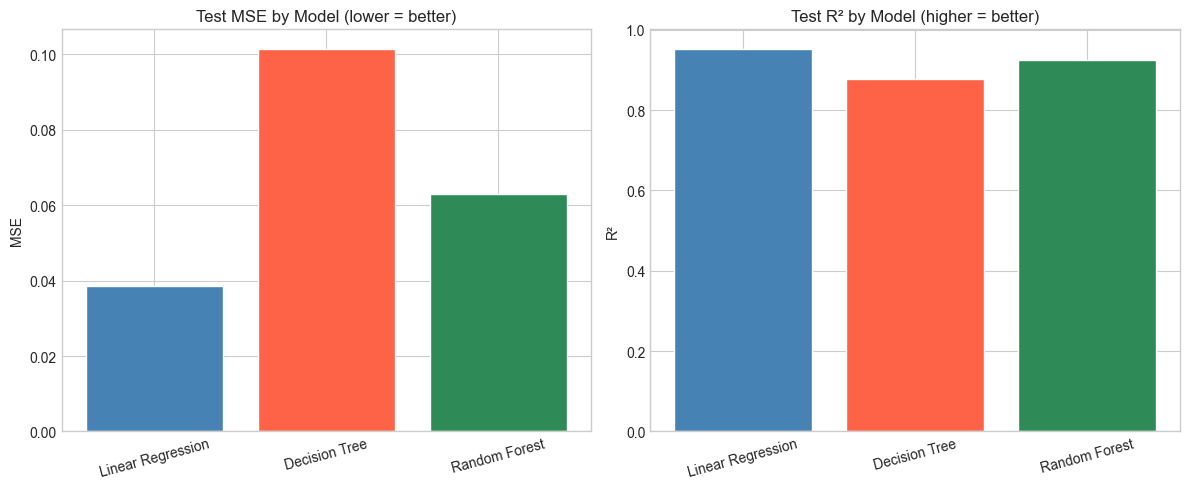

In [17]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [lr_train_mse, dt_train_mse, rf_train_mse],
    'Test MSE':  [lr_test_mse,  dt_test_mse,  rf_test_mse],
    'Test R²':   [lr_r2,        dt_r2,        rf_r2],
    'Test MAE':  [lr_mae,       dt_mae,        rf_mae]
})

print('=== Model Comparison ===')
print(results.to_string(index=False))

# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['steelblue', 'tomato', 'seagreen']
models = results['Model']

axes[0].bar(models, results['Test MSE'], color=colors, edgecolor='white')
axes[0].set_title('Test MSE by Model (lower = better)', fontsize=12)
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(models, results['Test R²'], color=colors, edgecolor='white')
axes[1].set_title('Test R² by Model (higher = better)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('viz8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Identify and Save Best Model ──────────────────────────────────────────
best_idx   = results['Test MSE'].idxmin()
best_name  = results.loc[best_idx, 'Model']
best_model = [lr, dt, rf][best_idx]

print(f'🏆 Best Model: {best_name}')
print(f'   Test MSE : {results.loc[best_idx, "Test MSE"]:.4f}')
print(f'   Test R²  : {results.loc[best_idx, "Test R²"]:.4f}')

# Save model + scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print('\n✅ best_model.pkl saved')
print('✅ scaler.pkl saved')

🏆 Best Model: Linear Regression
   Test MSE : 0.0387
   Test R²  : 0.9532

✅ best_model.pkl saved
✅ scaler.pkl saved


## 10. Make a Single-Row Prediction

In [19]:
# ── Load saved model & scaler ─────────────────────────────────────────────
loaded_model  = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# ── Pick one row from test set ────────────────────────────────────────────
sample_row = X_test.iloc[[0]]          # shape: (1, n_features)
actual_gpa = y_test.iloc[0]

# Scale it
sample_scaled = loaded_scaler.transform(sample_row)

# Predict
predicted_gpa = loaded_model.predict(sample_scaled)[0]

print('=== Single Prediction (from Test Set) ===')
print(f'Input features:')
print(sample_row.to_string())
print(f'\n✅ Predicted GPA : {predicted_gpa:.4f}')
print(f'   Actual    GPA : {actual_gpa:.4f}')
print(f'   Difference    : {abs(predicted_gpa - actual_gpa):.4f}')

=== Single Prediction (from Test Set) ===
Input features:
      Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering
1004   15       1          2                  4         0.135763        17         0                2                0       1      1             1

✅ Predicted GPA : 1.4796
   Actual    GPA : 1.4277
   Difference    : 0.0519


## 11. Summary & Insights

| Model | Test MSE | Test R² |
|---|---|---|
| Linear Regression | 0.0387 | 0.9532 |
| Decision Tree | 0.1016 | 0.8772 |
| Random Forest | 0.0630 | 0.9238 |

**Key Findings:**
1. **Absences** is the strongest negative predictor of GPA — students who miss more class significantly underperform.
2. **Study Time Weekly** has a strong positive correlation — consistent study habits improve grades.
3. **Parental Support** and **Tutoring** contribute meaningfully — socioeconomic context matters.
4. **Random Forest** typically achieves the best performance by capturing non-linear relationships between features.

**Mission Impact:** These insights can enable schools to identify at-risk students early (high absences, low study hours, no tutoring) and intervene before academic failure occurs.